# **Actividad 2**

### **Maestría en Inteligencia Artificial Aplicada**
### **Curso: Inteligencia Artificial y Aprendizaje Automático**


**Nombre del estudiante: William Frank Monroy Mamani**

**Matrícula: A00829796**

**NOTAS:**

*   Esta actividad la puedes realizar en Google-Colab.
*   Usaremos un conjunto de datos bastante conocido, llamado California_Housing o California_Housing_Prices. El objetivo en este caso es predecir el costo mediano de una casa en el estado de California, a partir de la información que se proporciona de la misma.
* Esta base de datos es muy conocida y a lo largo de los años ha sufrido muchas modificaciones, pero todas ellas siguen siendo utilizadas para su análisis.
*   En particular, en esta actividad usaremos los datos del archivo llamado california_housing_train.csv que se encuentra en la carpeta **sample_data**, en la sección de **Archivos** del Google-Colab que se encuentra en el menú ubicado a la izquierda.
* La información sobre el significado de las variables la puedes encontrar en la siguiente liga de Kaggle. Sin embargo, cabe mencionar que estrictamente los datos son diferentes a los del Google-Colab, por lo que solamente utiliza esta liga para obtener el significado de las variables: https://www.kaggle.com/datasets/camnugent/california-housing-prices

* Mencionamos también que el archivo california_housing_train.csv ya representa al conjunto de entrenamiento, por lo que no hace falta hacer una partición adicional para los análisis que estaremos haciendo.
*   Por otro lado, no es necesario trabajar con Google-Colab, puedes cargar y trabajar los datos en el entorno de desarrollo integrado (IDE) de tu preferencia.
* En esta actividad el código en Python ya está dado y no es necesario agregar más código. Sin embargo, si deseas incluir algún código adicional para justificar alguna de tus respuestas, lo puedes hacer, pero debes agregarlo en una nueva celda de código y no modificar en absoluto el código que ya está dado.
* Para responder a las preguntas de esta actividad, puedes apoyarte en alguna bibliografía del tema, o bien, mediante el uso de alguno de los llamados Modelos de Gran Tamaño, LLM, por sus siglas en inglés Large Language Model.
* Cuando utilices uno o varios LLM para responder una pregunta, deberás indicar cuál fue o fueron los utilizados. Por ejemplo, chatGPT, Copilot, Gemini, Claude, etc. De hecho, durante el presente curso nos estaremos apoyando constantemente en los modelos LLM.



In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

from sklearn.preprocessing import power_transform


In [2]:
# Si estás ejecutando este cuaderno de Jupyter desde Google Colab, podemos
# cargar el archivo desde la siguiente carpeta:
DIR = "/content/sample_data/"
os.chdir(DIR)

# Una vez cargado los datos de entrenamiento, obtenemos una descripción de cada variable:
misdatos = pd.read_csv("california_housing_train.csv", sep=",")
print("Dimensión del conjunto de entrenamiento:", misdatos.shape)
misdatos.describe()

Dimensión del conjunto de entrenamiento: (17000, 9)


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,17000.000000,17000.000000,17000.000000,17000.000000,17000.000000,17000.000000,17000.000000,17000.000000,17000.000000
mean,-119.562108,35.625225,28.589353,2643.664412,539.410824,1429.573941,501.221941,3.883578,207300.912353
std,2.005166,2.137340,12.586937,2179.947071,421.499452,1147.852959,384.520841,1.908157,115983.764387
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.790000,33.930000,18.000000,1462.000000,297.000000,790.000000,282.000000,2.566375,119400.000000
50%,-118.490000,34.250000,29.000000,2127.000000,434.000000,1167.000000,409.000000,3.544600,180400.000000
75%,-118.000000,37.720000,37.000000,3151.250000,648.250000,1721.000000,605.250000,4.767000,265000.000000
max,-114.310000,41.950000,52.000000,37937.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


# **Ejercicio 1 : Transformación de Variables**

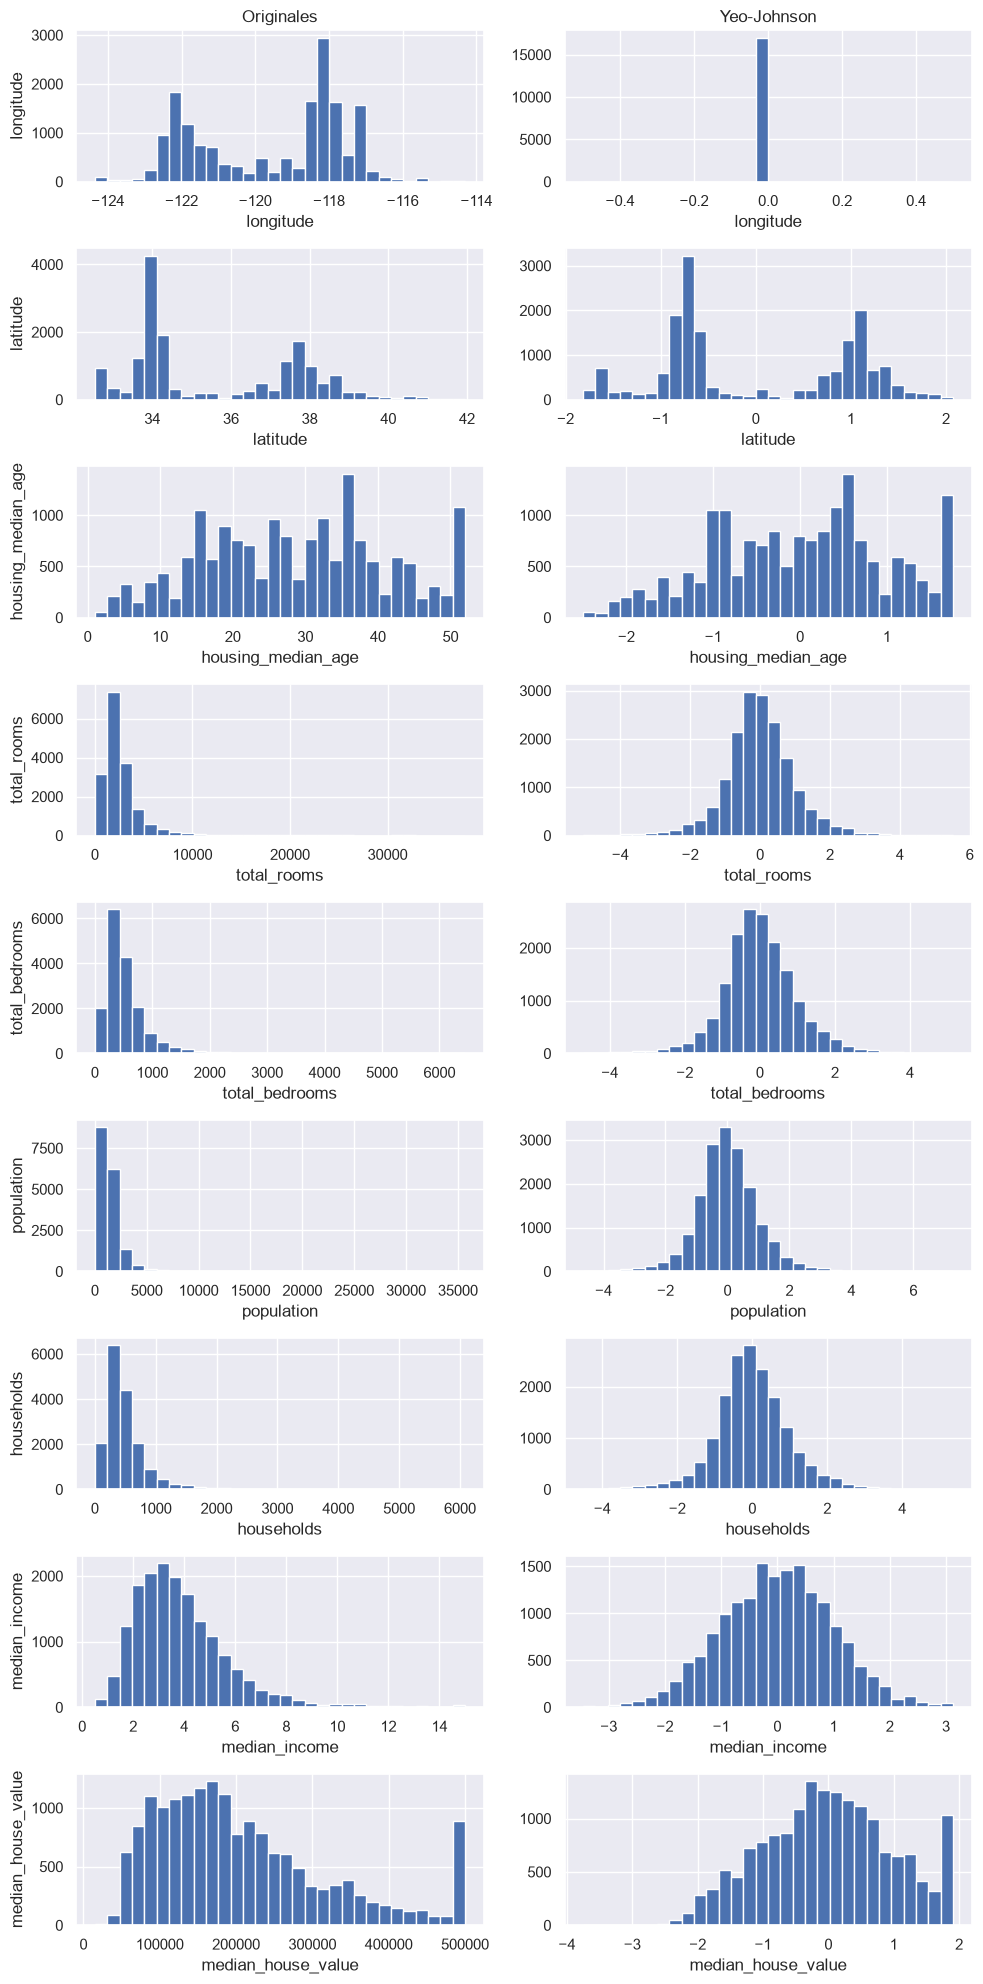

In [3]:
# NO DEBES MODIFICAR EL CóDIGO DE ESTA CELDA:

# Obtengamos los siguientes histogramas de los datos originales y sus transformaciones indicadas:

# Lista de las variables a transformar:
variables_a_transformar = ['longitude','latitude','housing_median_age','total_rooms',
                           'total_bedrooms','population','households','median_income',
                           'median_house_value']

yj = []  # para guardar las transformaciones obtenidas y usarlas más adelante con Pearson.

# Configuramos el entorno gráfico y mostramos los histogramas originales y los transformados:
sns.set(rc={'figure.figsize':(10,20)})
fig, axes = plt.subplots(len(variables_a_transformar),2)

for k in range(0, len(variables_a_transformar)):

    # Datos originales:
    Transf_originales = misdatos[variables_a_transformar[k]]

    plt.subplot(len(variables_a_transformar), 2, 2 * k + 1)
    plt.hist(Transf_originales, bins=30)
    plt.xlabel(variables_a_transformar[k])
    if k == 0:
        plt.title('Originales')
    plt.ylabel(variables_a_transformar[k]) # Esta es la etiqueta de cada variable.


    # Datos transformados con Yeo-Johnson:
    # La transformación .to_numpy().reshape(-1,1) es porque power_transform espera una entrada 2D
    Transf_yeojohnson = power_transform((Transf_originales.to_numpy()).reshape(-1,1), method ='yeo-johnson')
    yj.append(Transf_yeojohnson)

    plt.subplot(len(variables_a_transformar), 2, 2 * k + 2)
    plt.hist(Transf_yeojohnson, bins=30)
    plt.xlabel(variables_a_transformar[k])
    if k == 0:
        plt.title('Yeo-Johnson')

plt.tight_layout()
plt.show()

**Observa que las variables de entrada total_rooms, total_bedrooms, population y households, están claramente sesgadas positivamente. Y la variable de entrada median_income y la de salida median_house_value, un poco menos sesgadas.**



**PREGUNTAS:**

En los siguientes ejercicios supongamos que estamos analizando y preparando los datos para aplicar posteriormente un modelo de regresión lineal múltiple.

*   **Pregunta 1.1.** ¿Para qué se aplica usualmente la transformación Yeo-Johnson y cuál es su diferencia con Box-Cox?

*   **Pregunta 1.2.** ¿Cuál es la diferencia entre utilizar la métrica de la raíz cuadrada del error cuadrático medio RMSE (Root Mean Squared Error) y la del error absoluto medio MAE (Mean Absolute Error)? ¿Cuándo se recomienda utilizar cada uno?

*   **Pregunta 1.3.** Si vamos a aplicar posteriormente el modelo de regresión lineal múltiple y habiendo observado de los histogramas que las variables de entrada total_rooms, total_bedrooms, population, households y median_income tienen sesgos positivos ¿es recomendable aplicar alguna transformación de corrección de sesgo, como la mostrada de Yeo-Johnson en dichas variables? ¿Por qué?

*   **Pregunta 1.4.** Considerando ahora todas las variables de entrada de este problema, ¿es recomendable aplicarles alguna transformación de ajuste de escala (por ejemplo, la min-max, o la de normalización) antes de aplicar el modelo de regresión lineal múltiple? ¿Por qué?

*   **Pregunta 1.5.** Supongamos que ya decidiste aplicar la transformación Yeo-Johnson a las varibles sesgadas identificadas previamente. Una vez aplicada la Yeo-Johnson, ¿también es válido o recomendable aplicarles ahora una transformación de escala? ¿Por qué? En particular observa los histogramas resultantes con Yeo-Johnson obtenidos anteriormente para respaldar tu respuesta.

*   **Pregunta 1.6.** Supongamos que por alguna razón ya decidiste aplicar a las variables sesgadas tanto la transformación Yeo-Johnson, como la transformación de escala, ¿sería lo mismo aplicar primero la Yeo-Johnson seguida de la transformación de escala, que si lo hiciéramos al revés, es decir, primero la transformación de escala y luego la Yeo-Johnson? Justifica tu respuesta.

*   **Pregunta 1.7.** Observa ahora los histogramas de las variables de entrada originales "longitude" y "latitude". Claramente podríamos considerar a dichos histogramas como gráficos bimodales. ¿Qué se recomienda hacer en este caso? Es decir, ¿qué tipo de transformación o transformaciones se recomiendan aplicar? En particular, en este caso se observa que para estas variables la Yeo-Johnson no ayudó en absoluto.


*   **Pregunta 1.8.** Analicemos ahora la variable de salida median_house_value. ¿Cuál es ahora la recomendación para ajustar o transformar el sesgo o de corrección de escala? ¿Serían exactamente las mismas recomendaciones que se hicieron para las variables de entrada o se aplicaría un criterio diferente? Justifica tu respuesta.

*   **Pregunta 1.9.** Observa ahora el histograma de la variable de salida "median_house_value", ya sea la original o la transformada. Claramente se observa un "pico" al final de cualquiera de estos histogramas. ¿Qué transformación, criterio o recomendación adicional aplicaría para este tipo de gráficos?

### **Respuestas**

**1.1.** Sirve para que una variable muy cargada hacia un lado quede más pareja y se parezca más a una campana, y a diferencia de Box-Cox también funciona con ceros y números negativos.

**1.2.** Las dos miden en promedio cuánto se equivoca el modelo, pero RMSE castiga mucho más los errores grandes y MAE trata todos los errores igual. Por eso RMSE conviene cuando equivocarse por mucho es grave y MAE cuando hay valores fuera de lo normal.

**1.3.** Sí, porque con variables tan cargadas hacia un lado unos pocos valores muy grandes terminan dominando el modelo. En los histogramas se ve que con Yeo-Johnson quedan mucho más parejas, y eso le ayuda a la regresión lineal.

**1.4.** No es obligatorio para que el modelo prediga bien, pero sí es recomendable porque las variables están en escalas muy distintas. Así se pueden comparar entre ellas y funcionan mejor otros métodos que usemos después.

**1.5.** Sería válido, pero aquí ya no hace falta porque Yeo-Johnson ya dejó estas variables centradas en cero y en rangos parecidos. Solo faltaría escalar las que no se transformaron, como longitude, latitude y housing_median_age.

**1.6.** No es lo mismo, porque Yeo-Johnson cambia su resultado según la escala de los datos que recibe. Lo correcto es aplicar primero Yeo-Johnson y después escalar.

**1.7.** Estas variables no están cargadas hacia un lado, sino que tienen dos picos que corresponden a las dos zonas más pobladas de California, y por eso Yeo-Johnson no ayudó. Lo recomendable es solo escalarlas o convertirlas en regiones o en distancia a la costa.

**1.8.** El criterio es distinto, porque transformar el precio puede ayudar al modelo, pero después hay que regresar las predicciones a dólares para poder entenderlas. Escalarlo no hace falta.

**1.9.** Ese pico aparece porque todas las casas de 500 mil dólares o más se registraron con el mismo valor, así que no conocemos su precio real. Lo recomendable es quitar esas casas o conseguir su valor real, y aclarar que el modelo solo sirve para precios menores a ese límite.

# **Ejercicio - 2: Matriz de Correlación de Pearson**

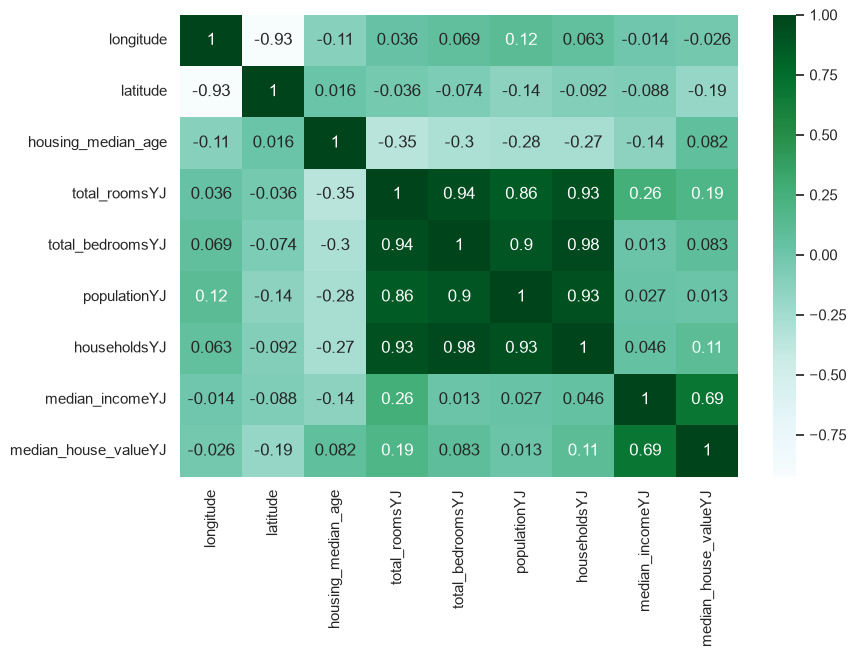

In [4]:
# NO DEBES MODIFICAR EL CóDIGO DE ESTA CELDA:

# Supongamos que obtenemos la matriz de correlación de Pearson, pero a las variables
# indicadas con YJ se les aplica ajuste de sesgo con Yeo-Johnson:
variables = ['longitude', 'latitude', 'housing_median_age', 'total_roomsYJ',
             'total_bedroomsYJ', 'populationYJ', 'householdsYJ', 'median_incomeYJ',
             'median_house_valueYJ']

# Creamos un nuevo DataFrame para almacenar las variables transformadas:
df_procesado = pd.DataFrame()

for var in variables:
    if var.endswith('YJ'):
        # Identificamos las variables del DataFrame origial a las cuales les aplicaremos Yeo-Johnson:
        col_origen = var if var in misdatos.columns else var[:-2]

        # Aplicamos la transformación Yeo-Johnson.
        # Usamos doble corchete ya que la función power_transform requiere un array 2D:
        df_procesado[var] = power_transform(misdatos[[col_origen]], method='yeo-johnson')
    else:
        # Las variables que no terminan en 'YJ' se copian directamente de los datos originales.
        df_procesado[var] = misdatos[var]

# Obtenemos la matriz de correlación de Pearson:
matriz_correlacion = df_procesado.corr(method='pearson')

sns.set(rc={'figure.figsize':(9,6)})
sns.heatmap(matriz_correlacion, annot=True, cmap='BuGn' )
plt.show()

**PREGUNTAS:**

*   **Pregunta 2.1.** ¿A qué tipo de variables (numéricas o categóricas) se aplica la matriz de correlación Pearson? ¿Y cuál es el objetivo de obtener dicha matriz?

*   **Pregunta 2.2.** Con respecto a la variable de salida, ¿qué variables de entrada están mayormente correlacionadas con ella? ¿Tiene sentido dentro del contexto y significado de las variables del problema?

*   **Pregunta 2.3.** En particular ¿cómo explicas el valor de correlación obtenido del factor "longitude" con respecto a la variable de salida transformada?

*   **Pregunta 2.4.** ¿Y cómo explicas el valor de correlación obtenido del factor "latitude" con respecto a la variable de salida transformada? ¿Tiene sentido con respecto al significado del problema?

*   **Pregunta 2.5.** Observa que con respecto a las variables de entrada y el concepto de multicolinealidad, varias de ellas tienen un alto valor de correlación de Pearson, ¿qué decisiones podemos tomar ahora con respecto a dichas variables?

### **Respuestas**

**2.1.** Se usa con variables numéricas y sirve para ver qué tan relacionadas están entre sí, tanto las entradas con el precio como las entradas entre ellas.

**2.2.** La variable más relacionada con el precio es median_income, con 0.69, y el resto tiene relaciones débiles. Tiene sentido, porque el ingreso de la zona define cuánto puede pagar la gente por una casa.

**2.3.** La correlación sale casi en cero (-0.03), pero no porque la ubicación no importe. El precio sube cerca de la costa y baja tierra adentro, y como la costa va en diagonal, avanzar de oeste a este no hace que el precio suba o baje de forma constante.

**2.4.** Es negativa y débil (-0.19), lo que indica que las casas tienden a ser un poco más caras al sur, donde están Los Ángeles y San Diego. La relación no es más fuerte porque al norte también está la Bahía de San Francisco, que es muy cara.

**2.5.** total_rooms, total_bedrooms, population y households están muy relacionadas entre sí (entre 0.86 y 0.98), así que casi dicen lo mismo. Conviene quedarse con una sola o convertirlas en datos por hogar, como cuartos por hogar o personas por hogar.

# **Ejercicio - 3: Conclusiones Finales**

**En particular, cuando hayas usado algún LLM, comenta qué tanto cambiaste a personalizaste las respuestas. Por ejemplo: ¿usaste todo el texto que te proporcionó o solo algunas partes?; ¿complementaste con varios LLM para cada respuesta? ¿Le hiciste preguntas adicionales, después de la primera?**



### **Conclusiones**

Me quedo con que buena parte del resultado de un modelo se decide antes de entrenarlo. La transformación depende de la forma de cada variable, porque Yeo-Johnson ayuda cuando una variable está cargada hacia un lado, pero no cuando tiene dos picos o un tope como el de 500,001. También vi que el orden de las transformaciones importa y que la correlación de Pearson puede engañar cuando la relación no es lineal, como pasa con la ubicación.

**Uso de herramientas de IA.** Usé un asistente de IA (LLM) como apoyo para ordenar mi entregable y como fuente para resolver dudas sobre la actividad.

### **Referencias**

Géron, A. (2022). *Hands-on machine learning with Scikit-Learn, Keras, and TensorFlow* (3a ed.). O'Reilly Media.

Nugent, C. (2017). *California housing prices* [Conjunto de datos]. Kaggle. https://www.kaggle.com/datasets/camnugent/california-housing-prices

Yeo, I.-K., y Johnson, R. A. (2000). A new family of power transformations to improve normality or symmetry. *Biometrika, 87*(4), 954-959. https://doi.org/10.1093/biomet/87.4.954